# HW3 - Tiny Unconditional Images

Question: what changes when the data is an image instead of a 2D point?


> CPU smoke run: this notebook is designed to execute quickly on CPU to verify mechanics, tensor shapes, plotting, and sampler logic. Generated samples may look like noise because the default training loop is intentionally tiny. Treat noisy samples as undertraining, not as evidence that the method is wrong. For meaningful visual quality, run longer on a GPU by increasing training steps, batch size, diffusion steps, and model width.


Sources:

- DDPM: https://arxiv.org/abs/2006.11239
- Diffusion Explainer: https://poloclub.github.io/diffusion-explainer/
- lucidrains DDPM: https://github.com/lucidrains/denoising-diffusion-pytorch


In [1]:
import math
import random
from pathlib import Path
from io import BytesIO

import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from IPython.display import Image, display

torch.manual_seed(7)
random.seed(7)
torch.set_num_threads(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


def show_plot():
    fig = plt.gcf()
    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=120)
    display(Image(data=buf.getvalue()))
    plt.close(fig)


device: cpu


In [2]:
COLORS = {
    "red": torch.tensor([1.0, 0.08, 0.08]),
    "green": torch.tensor([0.08, 0.80, 0.20]),
    "blue": torch.tensor([0.08, 0.25, 1.0]),
    "yellow": torch.tensor([1.0, 0.88, 0.08]),
}
SHAPES = ["circle", "square", "triangle"]


def draw_triangle(xx, yy, scale):
    # Upright triangle mask in normalized coordinates.
    top = yy > -scale
    left = yy < 2 * scale * (xx + scale)
    right = yy < -2 * scale * (xx - scale)
    return top & left & right & (yy < scale)


def make_shape_batch(batch=64, size=32, with_text=True):
    yy, xx = torch.meshgrid(
        torch.linspace(-1, 1, size),
        torch.linspace(-1, 1, size),
        indexing="ij",
    )
    images, captions = [], []
    for _ in range(batch):
        color_name = random.choice(list(COLORS))
        shape_name = random.choice(SHAPES)
        color = COLORS[color_name][:, None]
        scale = random.uniform(0.42, 0.72)
        img = torch.zeros(3, size, size)
        if shape_name == "circle":
            mask = xx.square() + yy.square() < scale**2
        elif shape_name == "square":
            mask = (xx.abs() < scale) & (yy.abs() < scale)
        else:
            mask = draw_triangle(xx, yy, scale)
        img[:, mask] = color
        images.append(img)
        captions.append(f"{color_name} {shape_name}")
    images = torch.stack(images)
    return (images, captions) if with_text else images


def show_images(images, titles=None, n=16, size=2.0):
    images = images.detach().cpu().clamp(0, 1)
    n = min(n, images.shape[0])
    cols = min(8, n)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * size, rows * size))
    axes = [axes] if n == 1 else axes.reshape(-1)
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            ax.imshow(images[i].permute(1, 2, 0))
            if titles:
                ax.set_title(titles[i], fontsize=8)
    plt.tight_layout()
    show_plot()


In [3]:
T = 8
betas = torch.linspace(1e-4, 0.05, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)


def q_sample(x0, t, eps=None):
    if eps is None:
        eps = torch.randn_like(x0)
    ab = alpha_bars[t].view(-1, *([1] * (x0.ndim - 1)))
    return ab.sqrt() * x0 + (1 - ab).sqrt() * eps, eps


@torch.no_grad()
def ddpm_sample(model, shape, cond=None, guidance_scale=None, cond_fn=None):
    x = torch.randn(shape, device=device)
    for ti in reversed(range(T)):
        t = torch.full((shape[0],), ti, device=device, dtype=torch.long)
        if guidance_scale is None:
            pred_eps = model(x, t) if cond is None else model(x, t, cond)
        else:
            eps_uncond = cond_fn(x, t, None)
            eps_cond = cond_fn(x, t, cond)
            pred_eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)
        beta, alpha, ab = betas[ti], alphas[ti], alpha_bars[ti]
        mean = (1 / alpha.sqrt()) * (x - beta / (1 - ab).sqrt() * pred_eps)
        x = mean if ti == 0 else mean + beta.sqrt() * torch.randn_like(x)
    return x


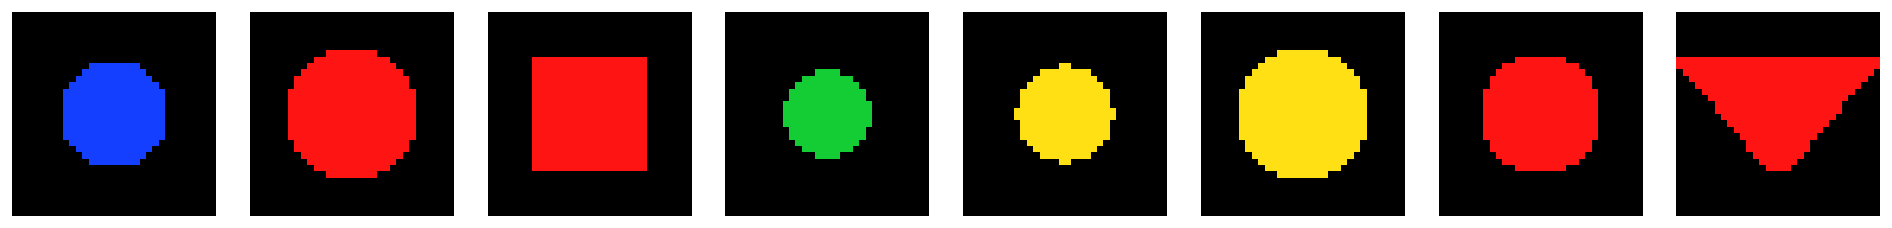

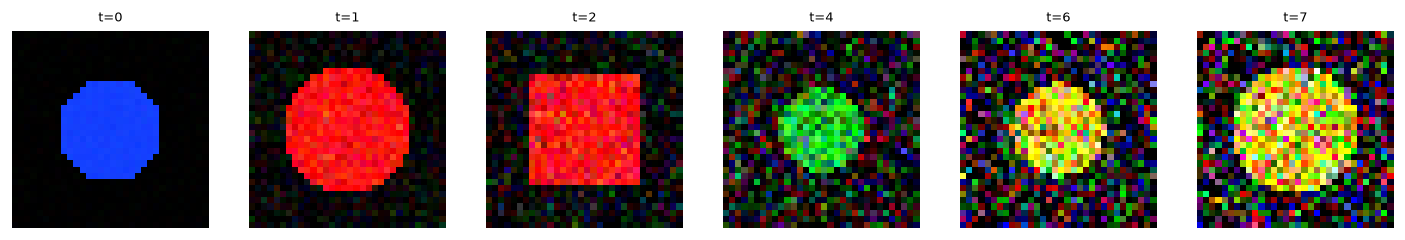

In [4]:
images = make_shape_batch(8, with_text=False)
show_images(images, n=8)

noisy_steps = [0, 1, 2, 4, 6, 7]
noisy, _ = q_sample(images[:6].to(device), torch.tensor(noisy_steps, device=device))
show_images(noisy, titles=[f"t={t}" for t in noisy_steps], n=6)


In [5]:
class TinyImageDenoiser(nn.Module):
    def __init__(self, channels=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(4, channels, 3, padding=1), nn.SiLU(),
            nn.Conv2d(channels, channels, 3, padding=1), nn.SiLU(),
            nn.Conv2d(channels, channels, 3, padding=1), nn.SiLU(),
            nn.Conv2d(channels, 3, 3, padding=1),
        )

    def forward(self, x, t):
        t_img = (t.float() / (T - 1)).view(-1, 1, 1, 1).expand(-1, 1, x.shape[2], x.shape[3])
        return self.net(torch.cat([x, t_img], dim=1))


model = TinyImageDenoiser().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=2e-3)


0 0.9986


5 0.9939


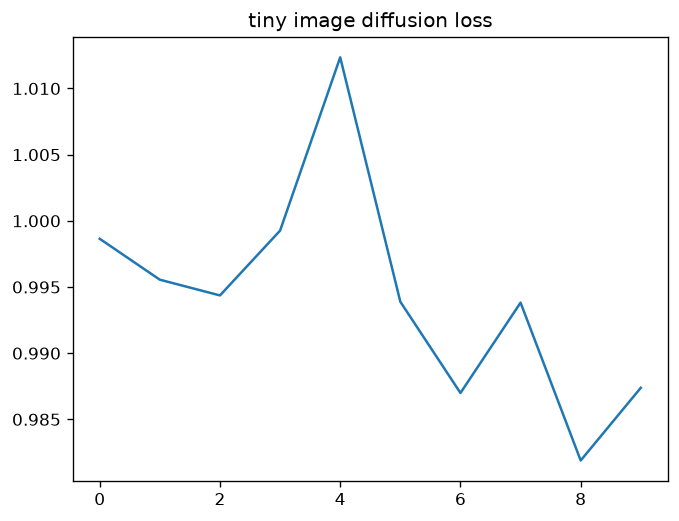

In [6]:
losses = []
for step in range(10):
    x0 = make_shape_batch(8, with_text=False).to(device)
    t = torch.randint(0, T, (x0.shape[0],), device=device)
    xt, eps = q_sample(x0, t)
    pred = model(xt, t)
    loss = F.mse_loss(pred, eps)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if step % 5 == 0:
        print(step, round(loss.item(), 4))

plt.plot(losses)
plt.title("tiny image diffusion loss")
show_plot()


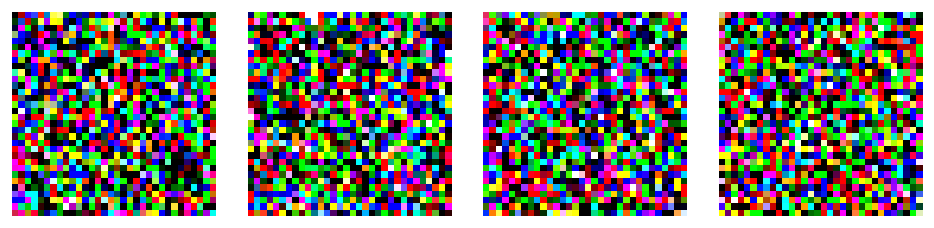

In [7]:
samples = ddpm_sample(model, (4, 3, 32, 32)).cpu()
show_images(samples, n=4)


## Interview Takeaway

Images are just high-dimensional points, but the model needs spatial bias. A plain MLP can work for tiny images, but convolutions or patch tokens make the image structure easier to learn.
